## Setup

In [3]:
from datetime import date
import silverfund.data_access_layer as dal

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

In [4]:
def cumulative_sum(returns):
    cum_sum = []
    current_sum = 0
    for r in returns:
        current_sum += r
        cum_sum.append(current_sum)
    return cum_sum

## Load and Select

In [16]:
w_polars = pl.read_parquet('2025_weights.parquet')

df_polars = pl.read_parquet('merged_output.parquet')

columns_to_drop = ['date', 'obsdate','enddate','cusip', 'ticker', 'issue_name',
                  'shrout_crsp','total_risk',
                   'ncusip_crsp','ticker_crsp','shrcd_crsp',
                   'exchcd_crsp','siccd_crsp','prc_crsp']
df_polars = df_polars.drop(columns_to_drop)

df_raw = df_polars.to_pandas()
w = w_polars.to_pandas()

In [6]:
w.head(1)

,date,barrid,weight
0,2025-01-27,USA06Z1,-0.018832


In [7]:
df_raw.head(1)

,DataDate,permno,barrid,ret_crsp,retx_crsp,vol_crsp,price_barra,mktcap_barra,ret_barra,spec_ret,spec_risk,HistBeta,PredBeta
0,1995-02-13,27385.0,None,0.003906,0.003906,14800.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [18]:
start_date = w.head(1)['date'].dt.date.iloc[0]
end_date = w.tail(1)['date'].dt.date.iloc[0]
df = df_raw.query('DataDate >= @start_date').reset_index()
df = df_raw.query('DataDate <= @end_date').reset_index()
df = df.loc[:, ['DataDate', 'barrid', 'ret_barra', 'mktcap_barra']]
df.rename(columns={'DataDate': 'date'}, inplace=True)
df

,date,barrid,ret_barra,mktcap_barra
0,1995-02-13,None,NaN,NaN
1,1995-02-14,None,NaN,NaN
2,1995-02-15,None,NaN,NaN
3,1995-02-16,None,NaN,NaN
4,1995-02-17,None,NaN,NaN
...,...,...,...,...
22147414,2024-12-02,USAQNP1,0.008395,5.815590e+08
22147415,2024-12-03,USAQNP1,-0.009137,5.762452e+08
22147416,2024-12-04,USAQNP1,0.021311,5.885259e+08
22147417,2024-12-05,USAQNP1,-0.003411,5.865185e+08


In [19]:
bt = df.merge(w, on=['date', 'barrid'], how='left')
bt

,date,barrid,ret_barra,mktcap_barra,weight
0,1995-02-13,None,NaN,NaN,NaN
1,1995-02-14,None,NaN,NaN,NaN
2,1995-02-15,None,NaN,NaN,NaN
3,1995-02-16,None,NaN,NaN,NaN
4,1995-02-17,None,NaN,NaN,NaN
...,...,...,...,...,...
22147414,2024-12-02,USAQNP1,0.008395,5.815590e+08,0.005406
22147415,2024-12-03,USAQNP1,-0.009137,5.762452e+08,0.001727
22147416,2024-12-04,USAQNP1,0.021311,5.885259e+08,0.010794
22147417,2024-12-05,USAQNP1,-0.003411,5.865185e+08,0.013394


In [20]:
bts = bt.query('weight == weight')
bts

,date,barrid,ret_barra,mktcap_barra,weight
22028955,2024-10-11,USBDOV1,-0.000647,9.159064e+08,-0.024298
22028956,2024-10-14,USBDOV1,0.000324,9.162031e+08,-0.023656
22028957,2024-10-15,USBDOV1,0.000324,9.164998e+08,-0.023697
22028958,2024-10-16,USBDOV1,0.000000,9.164998e+08,-0.020716
22028959,2024-10-17,USBDOV1,0.000647,9.170932e+08,-0.022080
...,...,...,...,...,...
22147414,2024-12-02,USAQNP1,0.008395,5.815590e+08,0.005406
22147415,2024-12-03,USAQNP1,-0.009137,5.762452e+08,0.001727
22147416,2024-12-04,USAQNP1,0.021311,5.885259e+08,0.010794
22147417,2024-12-05,USAQNP1,-0.003411,5.865185e+08,0.013394


## Portfolio and Backtest Results

In [21]:
bts['wr'] = bts['ret_barra']*bts['weight']
o_port = bts.groupby('date')['ret_barra'].mean()
m_port = bts.groupby('date')['wr'].mean()

/tmp/ipykernel_99589/1270005981.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  bts['wr'] = bts['ret_barra']*bts['weight']


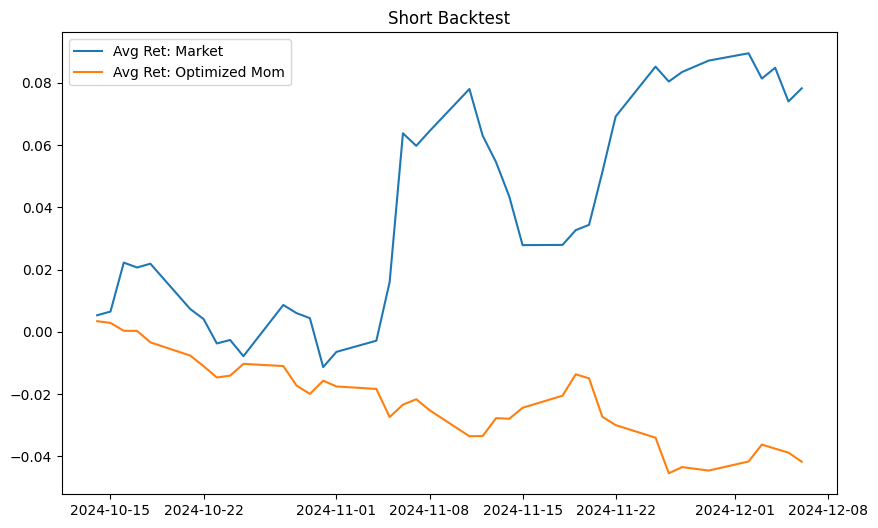

In [25]:
dates = o_port.index.get_level_values('date')[1:]

plt.figure(figsize=(10, 6))
plt.title('Short Backtest')
plt.plot(dates, cumulative_sum(o_port.values[1:]), label='Avg Ret: Market')
plt.plot(dates, cumulative_sum(m_port.values[1:]*100), label='Avg Ret: Optimized Mom')

plt.legend()
plt.show()